In [1]:
import numpy as np
import gempy as gp
import pandas as pd
import gempy_viewer as gpv
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import rasterio

Setting Backend To: AvailableBackends.numpy


In [2]:
#  ====
# Inputs
#  ====

x_lims = (369702.8, 374398.9)
y_lims = (407778.9, 411690.2)
z_lims = (300, -2000)

resolution = [100, 100, 60]   # nx, ny, nz
 
#  ====
extent = x_lims+y_lims+z_lims[::-1]

Active grids: GridTypes.NONE|TOPOGRAPHY|DENSE


c:\Users\ethan\anaconda3\envs\gempy310\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=Strat_Series1,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=unknown,
	color=#5DA629,
	is_active=True
),
Element(
	name=B1,
	color=#015482,
	is_active=True
),
Element(
	name=M1,
	color=#728f02,
	is_active=True
),
Element(
	name=B2,
	color=#9f0052,
	is_active=True
),
Element(
	name=M2,
	color=#443988,
	is_active=True
),
Element(
	name=B3,
	color=#ffbe00,
	is_active=True
),
Element(
	name=M3,
	color=#ff3f20,
	is_active=True
)
]
)
],
	fault_relations=
[[False]],

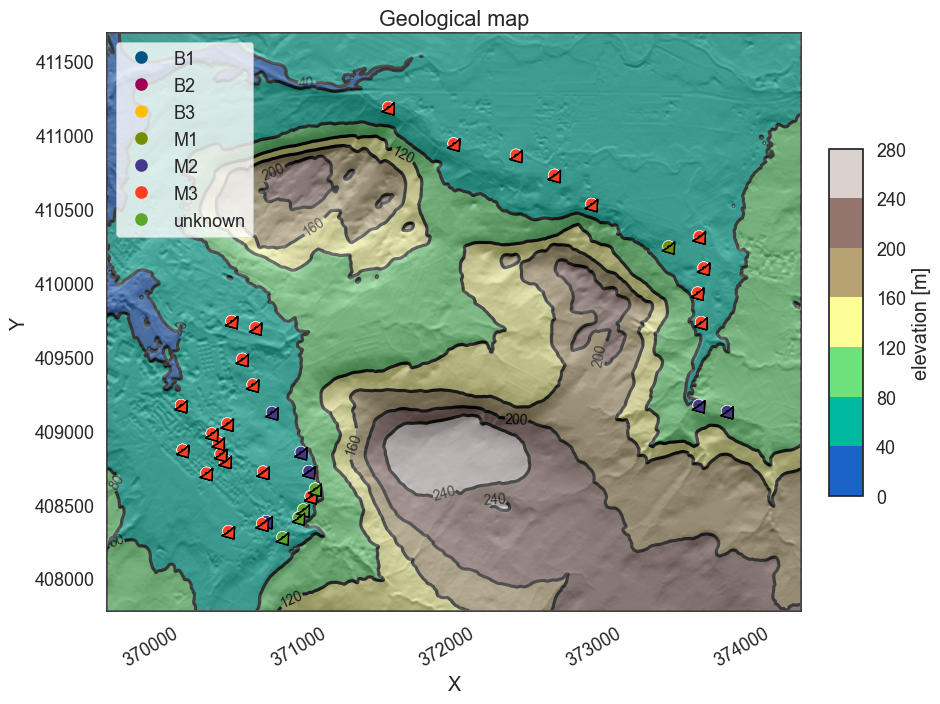

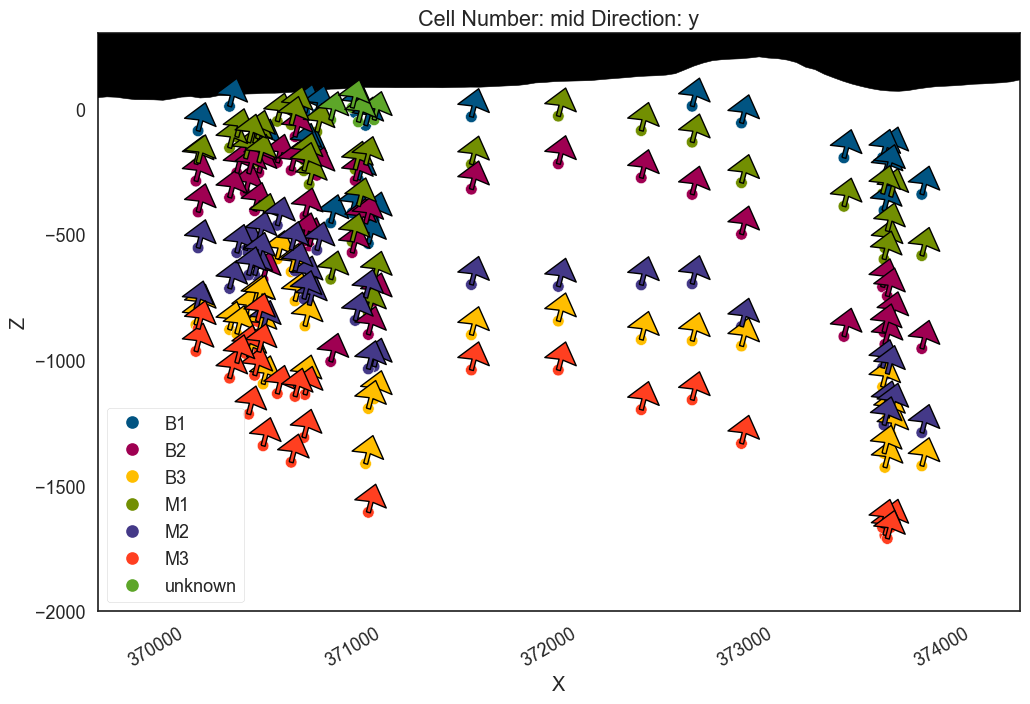

In [3]:
# Create instance of geomodel
geo_model = gp.create_geomodel(
    project_name = 'tutorial_model',
    extent=extent,
    resolution=resolution,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations='df_orientations_4gempy.csv',
        path_to_surface_points='df_surfaces_4gempy.csv'
    )
)

# Add topography
gp.set_topography_from_file(
    grid=geo_model.grid,
    filepath='../DEM/subset_dem.tif')

#Plot map
gpv.plot_2d(geo_model, show_topography=True, section_names=['topography'])

# Display a basic cross section of input data
gpv.plot_2d(geo_model, show_topography=True)

# Define structural groups and age/stratigraphic relationship
gp.map_stack_to_surfaces(
    gempy_model=geo_model,
    mapping_object={
        "Strat_Series1": ('unknown', 'B1', 'M1', 'B2', 'M2', 'B3', 'M3')
        }
)

In [4]:
# Compute a solution for the model
gp.compute_model(geo_model)

Setting Backend To: AvailableBackends.numpy
Chunking done: 1161 chunks


c:\Users\ethan\anaconda3\envs\gempy310\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 7 chunks
Chunking done: 35 chunks
Chunking done: 25 chunks


Solutions(4 Octree Levels, 7 DualContouringMeshes)

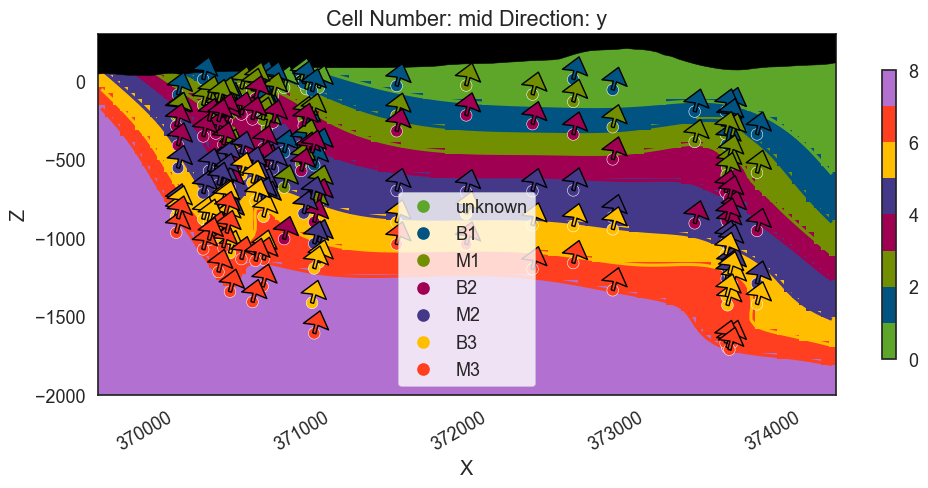

In [6]:
# Display the result in 2d section
gpv.plot_2d(geo_model, show_topography=True)

plotter = gpv.plot_3d(
    geo_model,
    show_lith=True,
    show_boundaries=True,
    ve=None,
    return_plotter=True
)

plotter.show()
plotter.close()

In [7]:
geo_model.grid.regular_grid.values

array([[ 3.69726280e+05,  4.07798457e+05, -1.98083333e+03],
       [ 3.69726280e+05,  4.07798457e+05, -1.94250000e+03],
       [ 3.69726280e+05,  4.07798457e+05, -1.90416667e+03],
       ...,
       [ 3.74375420e+05,  4.11670644e+05,  2.04166667e+02],
       [ 3.74375420e+05,  4.11670644e+05,  2.42500000e+02],
       [ 3.74375420e+05,  4.11670644e+05,  2.80833333e+02]],
      shape=(600000, 3))

In [8]:
geo_model.grid.values

array([[ 3.69726280e+05,  4.07798457e+05, -1.98083333e+03],
       [ 3.69726280e+05,  4.07798457e+05, -1.94250000e+03],
       [ 3.69726280e+05,  4.07798457e+05, -1.90416667e+03],
       ...,
       [ 3.74392800e+05,  4.11670149e+05,  7.15979309e+01],
       [ 3.74392800e+05,  4.11680174e+05,  7.18985138e+01],
       [ 3.74392800e+05,  4.11690200e+05,  7.25349503e+01]],
      shape=(783379, 3))

In [ ]:
lith = geo_model.solutions.raw_arrays.lith_block #* geo_model.solutions.raw_arrays.mask_matrix
res = geo_model.grid.regular_grid.resolution #10, 10, 60
lith_3d = lith.reshape(res)

lith_topo = lith_3d * (~geo_model.grid.topography.topography_mask) #why is it inverted?! :/

#lith_3d

#geo_model.solutions.raw_arrays.mask_matrix #wtf is this?

x = np.unique(geo_model.grid.regular_grid.values[:, 0])
y = np.unique(geo_model.grid.regular_grid.values[:, 1])
z = np.unique(geo_model.grid.regular_grid.values[:, 2])

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

#sanity check
print(x.shape, y.shape, z.shape)

#save the model
np.save("lith_topo.npy", lith_topo)
np.save('x_array.npy', x)
np.save('y_array.npy', y)
np.save('z_array.npy', z)

C:\Users\ethan\AppData\Local\Temp\ipykernel_4580\128893371.py:23: PyVistaDeprecationWarning: `xlabel` is deprecated. Use `xtitle` instead.
  plotter.show_bounds(
C:\Users\ethan\AppData\Local\Temp\ipykernel_4580\128893371.py:23: PyVistaDeprecationWarning: `ylabel` is deprecated. Use `ytitle` instead.
  plotter.show_bounds(
C:\Users\ethan\AppData\Local\Temp\ipykernel_4580\128893371.py:23: PyVistaDeprecationWarning: `zlabel` is deprecated. Use `ztitle` instead.
  plotter.show_bounds(
C:\Users\ethan\AppData\Local\Temp\ipykernel_4580\128893371.py:34: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


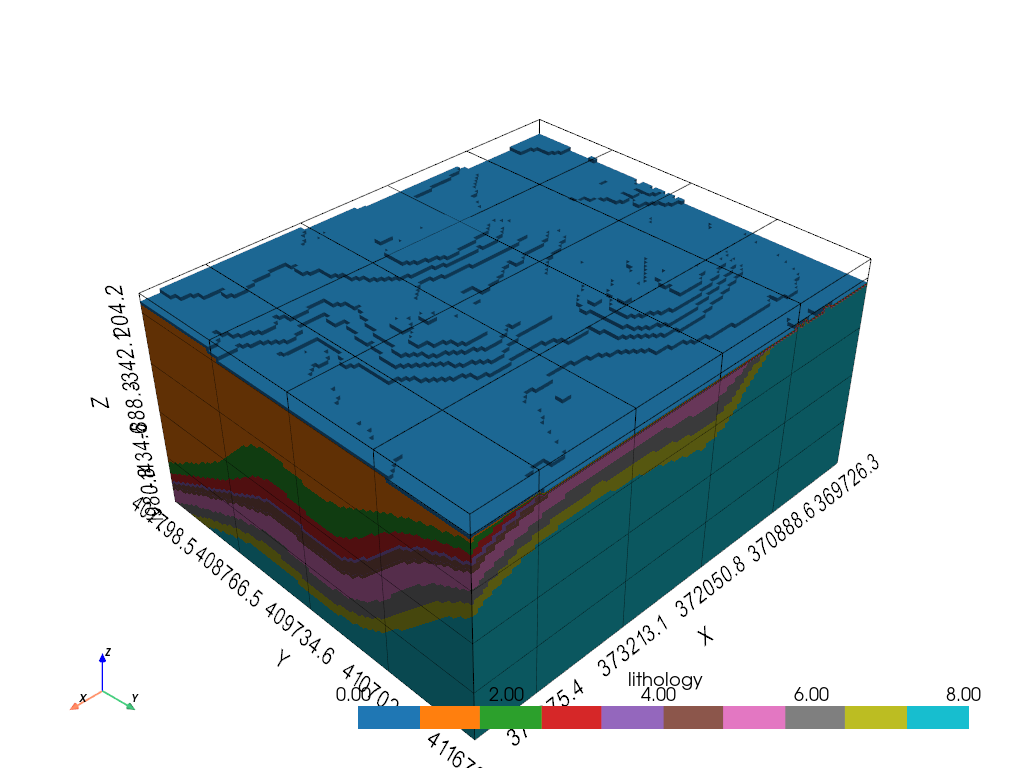

In [50]:
import numpy as np
import pyvista as pv

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

grid = pv.StructuredGrid(X, Y, Z)


grid["lithology"] = lith_topo.flatten(order="F")

# mask out 0 values
masked = grid.threshold([1., 8])

plotter = pv.Plotter()

plotter.add_mesh(
    masked,
    scalars='lithology',
    cmap="tab10",
    show_edges=False
)

plotter.show_bounds(
    grid="front",
    location="outer",
    all_edges=True,
    xlabel="X",
    ylabel="Y",
    zlabel="Z"
)

plotter.add_axes()

plotter.show()